<a href="https://colab.research.google.com/github/maxi9113/colab_notebook/blob/main/Taller_5_IC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En esta ocasión se toma como opcion diseñar el sistema fuzzy y su clasificación usando la libreria scikit-fuzzy debido a que los conceptos de universso de discurso funciones de pertencia y tipos de funciones se tienen claros

In [3]:
!pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.3 MB/s eta 0:00:00


* Utilizar 200 puntos de discretización para todos los universoso de discurso.

In [16]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# === 1. UNIVERSOS DE DISCURSO ===
vf = np.linspace(0, 1.8, 200)     # Tensión fundamental (p.u.)
thd = np.linspace(0, 100, 200)    # Distorsión armónica total (%)
cls = np.linspace(0, 1, 200)      # Clase normalizada

# === 2. FUNCIONES DE PERTENENCIA ===
vf_muy_baja = fuzz.trapmf(vf, [0.00, 0.00, 0.09, 0.12])
vf_baja     = fuzz.trapmf(vf, [0.09, 0.12, 0.94, 0.96])
vf_media    = fuzz.trapmf(vf, [0.94, 0.96, 1.04, 1.06])
vf_alta     = fuzz.trapmf(vf, [1.04, 1.10, 1.80, 1.80])

thd_pequena = fuzz.trapmf(thd, [0, 0, 5, 6])
thd_grande  = fuzz.trapmf(thd, [5, 7, 100, 100])

forma_I  = fuzz.trimf(cls, [0.000, 0.167, 0.333])
forma_HT = fuzz.trimf(cls, [0.167, 0.333, 0.500])
forma_ON = fuzz.trimf(cls, [0.333, 0.500, 0.667])
forma_PT = fuzz.trimf(cls, [0.500, 0.667, 0.833])
forma_PA = fuzz.trimf(cls, [0.667, 0.833, 1.000])




Se procede a dibujar las funcoens de perteneica y el sistema difuso

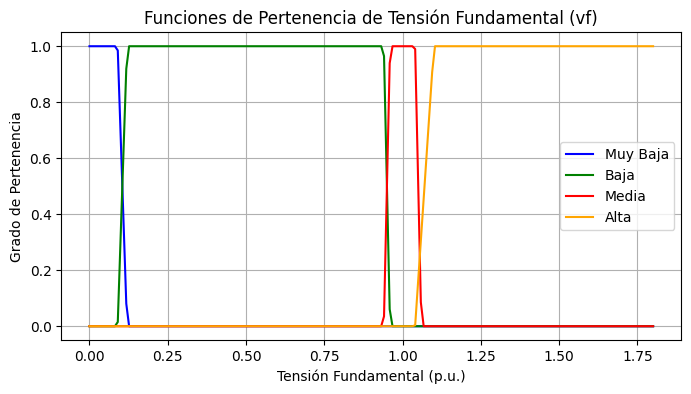

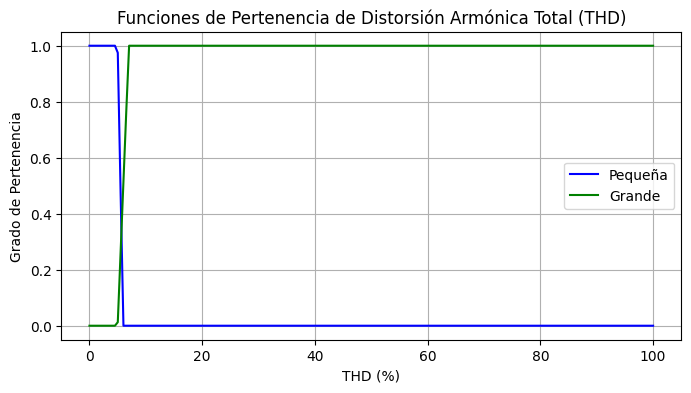

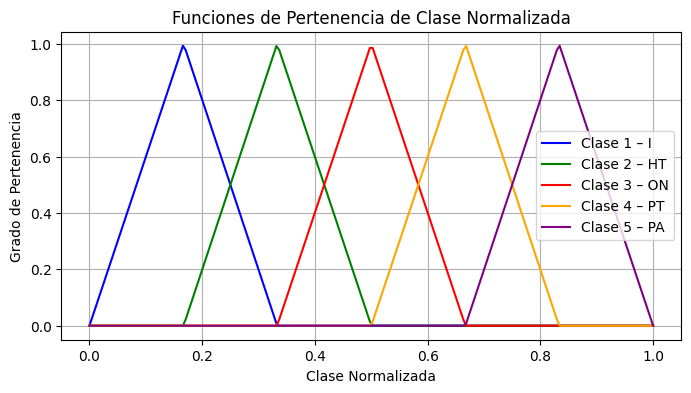

In [24]:
# === 3. VISUALIZACIÓN DE FUNCIONES DE PERTENENCIA ===

# Tensión fundamental (vf)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(vf, vf_muy_baja, 'b', linewidth=1.5, label='Muy Baja')
ax.plot(vf, vf_baja, 'g', linewidth=1.5, label='Baja')
ax.plot(vf, vf_media, 'r', linewidth=1.5, label='Media')
ax.plot(vf, vf_alta, 'orange', linewidth=1.5, label='Alta')
ax.set_title('Funciones de Pertenencia de Tensión Fundamental (vf)')
ax.set_xlabel('Tensión Fundamental (p.u.)')
ax.set_ylabel('Grado de Pertenencia')
ax.legend()
ax.grid(True)
plt.show()

# Distorsión armónica total (thd)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thd, thd_pequena, 'b', linewidth=1.5, label='Pequeña')
ax.plot(thd, thd_grande, 'g', linewidth=1.5, label='Grande')
ax.set_title('Funciones de Pertenencia de Distorsión Armónica Total (THD)')
ax.set_xlabel('THD (%)')
ax.set_ylabel('Grado de Pertenencia')
ax.legend()
ax.grid(True)
plt.show()

# Clase normalizada (cls)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cls, forma_I, 'b', linewidth=1.5, label='Clase 1 – I')
ax.plot(cls, forma_HT, 'g', linewidth=1.5, label='Clase 2 – HT')
ax.plot(cls, forma_ON, 'r', linewidth=1.5, label='Clase 3 – ON')
ax.plot(cls, forma_PT, 'orange', linewidth=1.5, label='Clase 4 – PT')
ax.plot(cls, forma_PA, 'purple', linewidth=1.5, label='Clase 5 – PA')
ax.set_title('Funciones de Pertenencia de Clase Normalizada')
ax.set_xlabel('Clase Normalizada')
ax.set_ylabel('Grado de Pertenencia')
ax.legend()
ax.grid(True)
plt.show()

Se realiza un fuzzy clasificador donde se tiene en cuenta lo siguiente

* Utilizar operador  de composición de tipo Max-Min.
* Utilizar como operador de implicación el operador Mamdani
*	Utilizar como operador de agregación el operador Maximo
*	Utilizar el operador Minimo para el conectivo Y

In [28]:
# === CLASIFICADOR FUZZY ===
def fuzzy_clasificador(vf_input, thd_input):
    # 4. Fuzzificación
    vf_level_mb = fuzz.interp_membership(vf, vf_muy_baja, vf_input)
    vf_level_b  = fuzz.interp_membership(vf, vf_baja, vf_input)
    vf_level_m  = fuzz.interp_membership(vf, vf_media, vf_input)
    vf_level_a  = fuzz.interp_membership(vf, vf_alta, vf_input)

    thd_level_p = fuzz.interp_membership(thd, thd_pequena, thd_input)
    thd_level_g = fuzz.interp_membership(thd, thd_grande, thd_input)

    # 5. Reglas difusas
    #Regla 1 🡪 Si Vf es MB y THD es P entonces Salida es I.
    #Regla #2 🡪 Si Vf es B y THD es P entonces Salida es HT. Regla
    #3 🡪 Si Vf es M y THD es P entonces Saída es ON. Regla
    #4 🡪 Si Vf es A y THD es P entonces Saída es PT. Regla
    #5 🡪 Si Vf es MB y THD es G entonces Saída es I. Regla
    #6 🡪 Si Vf es B y THD es G entonces Saída es PA. Regla
    #7 🡪 Si Vf es M y THD es G entonces Saída es PA. Regla
    #8 🡪 Si Vf es Al y THD es G entonces Saída es PA.
    rule1 = np.fmin(vf_level_mb, thd_level_p)
    rule2 = np.fmin(vf_level_b,  thd_level_p)
    rule3 = np.fmin(vf_level_m,  thd_level_p)
    rule4 = np.fmin(vf_level_a,  thd_level_p)
    rule5 = np.fmin(vf_level_mb, thd_level_g)
    rule6 = np.fmin(vf_level_b,  thd_level_g)
    rule7 = np.fmin(vf_level_m,  thd_level_g)
    rule8 = np.fmin(vf_level_a,  thd_level_g)

    # 6. Activación de consecuentes
    activation_I  = np.fmax(rule1, rule5)
    activation_HT = rule2
    activation_ON = rule3
    activation_PT = rule4
    activation_PA = np.fmax(np.fmax(rule6, rule7), rule8)

    cls_activation_I  = np.fmin(activation_I,  forma_I)
    cls_activation_HT = np.fmin(activation_HT, forma_HT)
    cls_activation_ON = np.fmin(activation_ON, forma_ON)
    cls_activation_PT = np.fmin(activation_PT, forma_PT)
    cls_activation_PA = np.fmin(activation_PA, forma_PA)

    # 7. Agregación
    aggregated = np.fmax(cls_activation_I,
                np.fmax(cls_activation_HT,
                np.fmax(cls_activation_ON,
                np.fmax(cls_activation_PT, cls_activation_PA))))

    # 8. Defuzzificación
    cls_defuzz = fuzz.defuzz(cls, aggregated, 'lom')
    cls_result = fuzz.interp_membership(cls, aggregated, cls_defuzz)

    return cls_defuzz, cls_result


De acuerdo a los terminios linguisticos y a las tablas entregadas se diseña el clasificador

In [22]:
# === FUNCIÓN DE CLASIFICACIÓN ===
def clasificar_salida(y):
    if 0.00 < y <= 0.25:
        return "Clase 1 – I"
    elif 0.25 < y <= 0.42:
        return "Clase 2 – HT"
    elif 0.42 < y <= 0.58:
        return "Clase 3 – ON"
    elif 0.58 < y <= 0.75:
        return "Clase 4 – PT"
    elif 0.75 < y <= 1.00:
        return "Clase 5 – PA"
    else:
        return "Fuera de rango"


Se entrega el resultado de sistema fuzzy clasificador de acuerdor a las situaciones expuestas

In [26]:
#situaciones Vf / THD
situaciones = [
    (0.01, 0.34),
    (0.05, 16.26),
    (0.50, 4.84),
    (0.85, 1.79),
    (1.02, 0.47),
    (0.97, 1.21),
    (1.57, 4.76),
    (1.26, 1.21),
    (0.99, 16.32),
    (1.20, 18.96),
]

for vf_input, thd_input in situaciones:
    cls_defuzz, cls_result = fuzzy_clasificador(vf_input, thd_input)
    clasificacion = clasificar_salida(cls_defuzz)

    print(f"Vf: {vf_input}, THD: {thd_input} -> {cls_defuzz:.4f}, Clase: {clasificacion}")

Vf: 0.01, THD: 0.34 -> 0.1658, Clase: Clase 1 – I
Vf: 0.05, THD: 16.26 -> 0.1658, Clase: Clase 1 – I
Vf: 0.5, THD: 4.84 -> 0.3317, Clase: Clase 2 – HT
Vf: 0.85, THD: 1.79 -> 0.3317, Clase: Clase 2 – HT
Vf: 1.02, THD: 0.47 -> 0.5025, Clase: Clase 3 – ON
Vf: 0.97, THD: 1.21 -> 0.5025, Clase: Clase 3 – ON
Vf: 1.57, THD: 4.76 -> 0.6683, Clase: Clase 4 – PT
Vf: 1.26, THD: 1.21 -> 0.6683, Clase: Clase 4 – PT
Vf: 0.99, THD: 16.32 -> 0.8342, Clase: Clase 5 – PA
Vf: 1.2, THD: 18.96 -> 0.8342, Clase: Clase 5 – PA
